In [2]:

import nibabel as nib
import numpy as np
from sklearn.decomposition import PCA
import os
import pandas as pd

def load_4d_niftis(nifti_path, mask_path=None):
    """
    Load 4D niftis and return a 2D numpy array
    """
    niftis = nib.load(nifti_path)
    print("Get niftis data...")
    niftis_data = niftis.get_fdata()
    print("Shape: ", niftis_data.shape)
    niftis_data = np.reshape(niftis_data, (niftis_data.shape[0]*niftis_data.shape[1]*niftis_data.shape[2], niftis_data.shape[3]))
    print("After reshaping: ", niftis_data.shape)

    if mask_path is not None:
        print("Loading mask...")
        mask = nib.load(mask_path).get_fdata()
        mask = np.reshape(mask, (mask.shape[0]*mask.shape[1]*mask.shape[2]))
        niftis_data = niftis_data[mask > 0, :]
        print("After masking:", niftis_data.shape)
    
    # transpose to have shape (n_samples, n_features)
    niftis_data = np.transpose(niftis_data)
    return niftis_data

def run_pca(X, n_components):
    """
    Run PCA on data
    """
    pca = PCA(n_components=n_components)
    print(X.shape)
    pca_fit = pca.fit(X)
    X_pca = pca.transform(X)
    print(X_pca.shape)

    print("Explained variance ratios of components:")
    print(pca_fit.explained_variance_ratio_)
    return X_pca, pca_fit.explained_variance_ratio_

def read_sub_list(sub_list_path):
    """
    Read subject list
    """
    with open(sub_list_path) as f:
        sub_list = f.readlines()
    sub_list = [x.strip() for x in sub_list]
    return sub_list

def load_subs_from_file_list(fn):
    return [int(x.split("/")[-3]) for x in sorted(list(open(fn).read().split('\n')))[1:]]

def get_subj_names2(fn):
    subs_in_file1 = open(fn)
    return [ int(x) for x in list(subs_in_file1.read().split('\n'))[:-1] ]

def make_df(in_data, sub_list):
    """
    Make a dataframe
    """
    df = pd.DataFrame(in_data, index=sub_list, columns=["PC"+str(i) for i in range(in_data.shape[1])])
    return df

def save_df(df, out_path):
    """
    Save dataframe
    """
    df.to_csv(out_path, index=True, sep="\t")

def main(nifti_path, sub_list, out_path, n_components, n_subs=None, mask_path=None):
    """
    Main function
    """
    print("Loading data...")	
    data = load_4d_niftis(nifti_path, mask_path=mask_path)

    print("Running PCA...")
    X_pca, expl_var = run_pca(data, n_components)
    
    print("Making dataframe...")
    #sub_list = read_sub_list(sub_list_path)
    out_df = make_df(X_pca, sub_list)
    expl_var = pd.DataFrame(expl_var, index=["PC"+str(i) for i in range(len(expl_var))], columns=["explained_variance"])

    print("Saving dataframe...")
    save_df(out_df, out_path)
    save_df(expl_var, out_path.replace(".tsv", "_expl_var.tsv"))
    del data


#paths
workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/"
cfs_path = "/data/clusterfs/lag/users/jitame/CONGRADS/pheno"
congrads_base_path = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/"

#files = "afd/afd.nii.gz rs_ifl/ica_ifl.nii.gz rs_mtl/ica_mtl.nii.gz tbm/tbm_log_masked.nii.gz".split(" ")
#files = "dMRI/dMRI_100.nii.gz  rs_ifl/ica_ifl_mni_100.nii.gz  rs_mtl/ica_mtl_mni_100.nii.gz  tbm/tbm_100.nii.gz".split("  ")
files_g1 = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/all_data_lifg_g1_cmap_template.nii.gz",
        "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lifg/all_data_lifg_g1_pmap_template.nii.gz",
        "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_template.nii.gz",
         "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lstg/all_data_lstg_g1_pmap_template.nii.gz"
        ]

files_g2 = [fn.replace("g1", "g2") for fn in files_g1]

files = files_g1 + files_g2

print(files)

#mni_mask="/usr/shared/apps/fsl/6.0.3/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"
mask="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lifg.nii.gz"
mask_pmap="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lifg_pmap.nii.gz"
mask_lstg="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lstg.nii.gz"
mask_lstg_pmap="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lstg_pmap.nii.gz"
masks = [mask, mask_pmap, mask_lstg, mask_lstg_pmap] * 2

file_lists_g1 = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/file_list_template.txt",
        "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lifg/file_list_template.txt",
        "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/file_list_template.txt",
         "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lstg/file_list_template.txt"
        ]

file_lists_g2 = [fn.replace("g1", "g2") for fn in file_lists_g1]

file_lists = file_lists_g1 + file_lists_g2

base_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/"
roi="lifg" #"lstg" 

file_list_non_temp = os.path.join(base_path, roi, "file_list_non_template.txt")

# run pca
for i, f in enumerate(files):
    nifti_path = f
    out_path = os.path.join(workspace_path, os.path.split(f)[1].replace(".nii.gz", "_pca.tsv"))
    sub_list = load_subs_from_file_list(file_lists[i])
    print("Nifti: ", nifti_path)
    print("Out: ", out_path)
    print("Mask: ", masks[i])
    main(nifti_path=nifti_path,
        sub_list = sub_list,
        out_path=out_path,
        n_components=10,
        n_subs=None,
        mask_path=masks[i]
        )

['/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/all_data_lifg_g1_cmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lifg/all_data_lifg_g1_pmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/pmap/lstg/all_data_lstg_g1_pmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g2/cmap/lifg/all_data_lifg_g2_cmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g2/pmap/lifg/all_data_lifg_g2_pmap_template.nii.gz', '/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g2/cmap/lstg/all_data_lstg_g2_cmap_template.

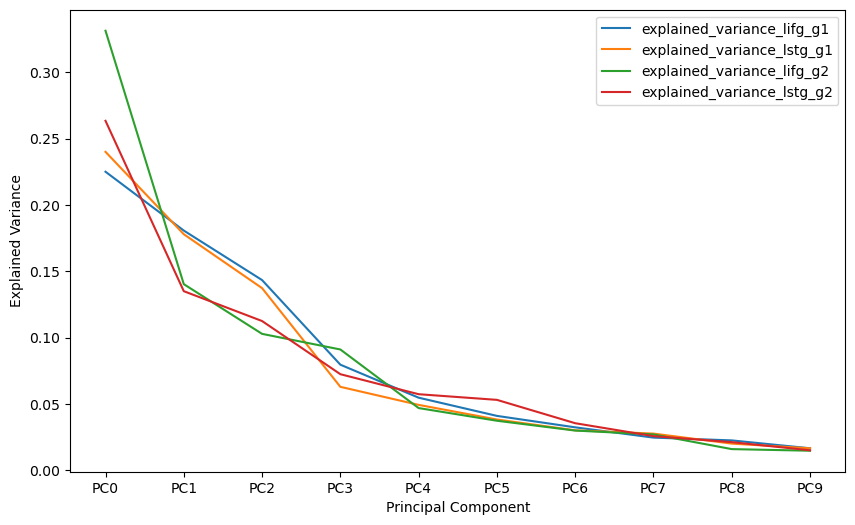

In [6]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

workspace_path = r"P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest"

df_fns = glob.glob(os.path.join(workspace_path, "all_data_*_cmap_template_pca_expl_var.tsv"))

df = pd.DataFrame()

for fn in df_fns:
    expl_var = pd.read_csv(fn, sep="\t", index_col=0, header=None, skiprows=1)
    expl_var.columns = ["explained_variance_{}".format(os.path.split(fn)[1].replace("all_data_", "").replace("_cmap_template_pca_expl_var.tsv", ""))]
    df = pd.concat([df, expl_var], axis=1)

plt.figure(figsize=(10,6))

import seaborn as sns

sns.lineplot(data=df, dashes=False)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.savefig(os.path.join(workspace_path, "pca_explained_variance.png"), dpi=300)